In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')




Saving cleaned_credit.csv to cleaned_credit.csv
User uploaded file "cleaned_credit.csv" with length 7221280 bytes


In [3]:
df = pd.read_csv("cleaned_credit.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (149986, 11)


,default,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [4]:
default_rate = df["default"].mean()
print(f"Overall Default Rate: {default_rate:.2%}")


Overall Default Rate: 6.68%


In [5]:
df["income_bucket"] = pd.qcut(
    df["MonthlyIncome"],
    q=5,
    duplicates="drop"
)


/tmp/ipython-input-2256879319.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_default = df.groupby("income_bucket")["default"].mean()


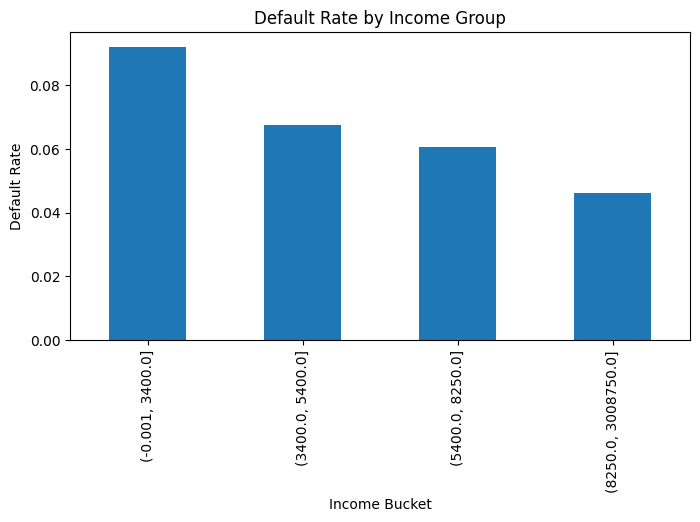

In [ ]:
income_default = df.groupby("income_bucket")["default"].mean()

income_default.plot(kind="bar", figsize=(8,4))
plt.title("Default Rate by Income Group")
plt.ylabel("Default Rate")
plt.xlabel("Income Bucket")
plt.show()


In [ ]:
df["income_bucket"] = pd.qcut(
    df["MonthlyIncome"],
    q=5,
    duplicates="drop"
)



/tmp/ipython-input-2256879319.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_default = df.groupby("income_bucket")["default"].mean()


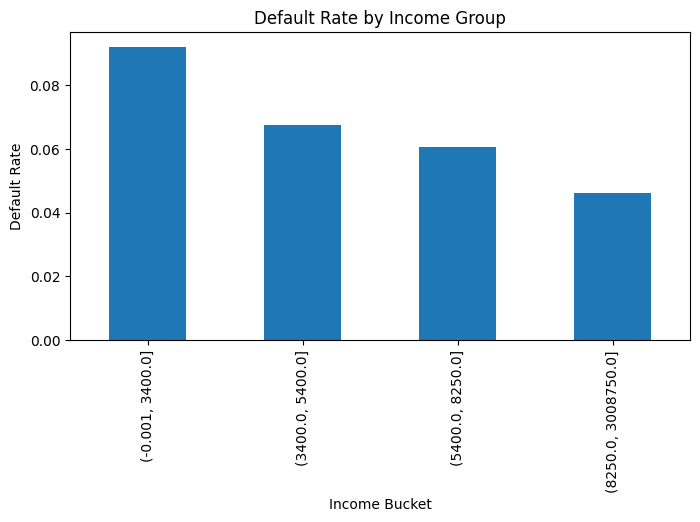

In [ ]:
income_default = df.groupby("income_bucket")["default"].mean()

income_default.plot(kind="bar", figsize=(8,4))
plt.title("Default Rate by Income Group")
plt.ylabel("Default Rate")
plt.xlabel("Income Bucket")
plt.show()


/tmp/ipython-input-1021501581.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  debt_default = df.groupby("debt_bucket")["default"].mean()


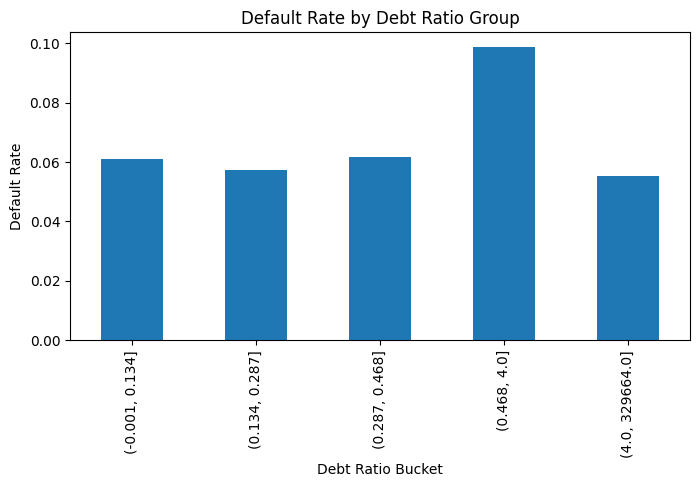

In [ ]:
df["debt_bucket"] = pd.qcut(
    df["DebtRatio"],
    q=5,
    duplicates="drop"
)

debt_default = df.groupby("debt_bucket")["default"].mean()

debt_default.plot(kind="bar", figsize=(8,4))
plt.title("Default Rate by Debt Ratio Group")
plt.ylabel("Default Rate")
plt.xlabel("Debt Ratio Bucket")
plt.show()


/tmp/ipython-input-659090532.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_default = df.groupby("age_bucket")["default"].mean()


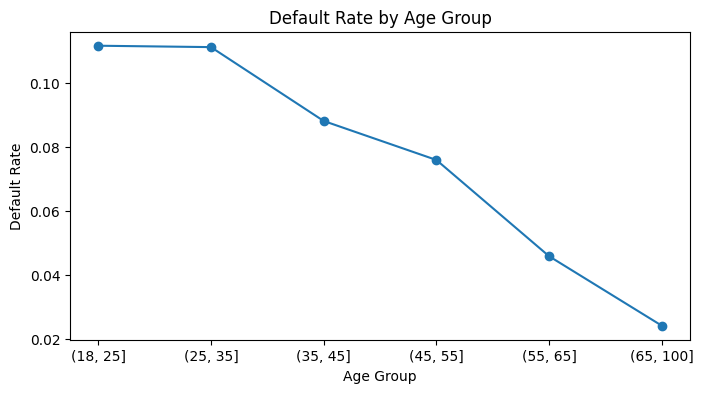

In [ ]:
df["age_bucket"] = pd.cut(
    df["age"],
    bins=[18,25,35,45,55,65,100]
)

age_default = df.groupby("age_bucket")["default"].mean()

age_default.plot(kind="line", marker="o", figsize=(8,4))
plt.title("Default Rate by Age Group")
plt.ylabel("Default Rate")
plt.xlabel("Age Group")
plt.show()


## Summary of Exploratory Findings

- Default risk is higher among low-income and high-debt borrowers
- Past delinquency history is the strongest predictor of default
- Credit risk varies non-linearly across age groups
- These findings are consistent with real-world lending intuition and guide model design


# Credit Risk Modeling

## Objective
The objective of this notebook is to build an interpretable credit risk model to estimate the probability of borrower default.

The focus is on:
- Predicting default probability
- Using explainable models suitable for banking and fintech applications
- Evaluating model performance using risk-appropriate metrics

Logistic regression is used as the baseline model due to its interpretability and widespread use in credit risk analytics.


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_credit.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (149986, 11)


,default,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [ ]:
df["any_past_due"] = (
    (df["NumberOfTime30-59DaysPastDueNotWorse"] > 0) |
    (df["NumberOfTime60-89DaysPastDueNotWorse"] > 0) |
    (df["NumberOfTimes90DaysLate"] > 0)
).astype(int)

In [ ]:
df[[
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "any_past_due"
]].head()

,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,any_past_due
0,2,0,0,1
1,0,0,0,0
2,1,0,1,1
3,0,0,0,0
4,1,0,0,1


In [ ]:
FEATURES = [
    "MonthlyIncome",
    "DebtRatio",
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "any_past_due"
]

X = df[FEATURES]
y = df["default"]


In [ ]:
X.head()


,MonthlyIncome,DebtRatio,RevolvingUtilizationOfUnsecuredLines,age,any_past_due
0,9120.0,0.802982,0.766127,45,1
1,2600.0,0.121876,0.957151,40,0
2,3042.0,0.085113,0.658180,38,1
3,3300.0,0.036050,0.233810,30,0
4,63588.0,0.024926,0.907239,49,1


# Credit Decision Framework

## Objective
The objective of this notebook is to convert predicted default probabilities into
practical lending decisions.

This step bridges the gap between predictive modeling and real-world fintech lending
by introducing:
- Risk-based approval thresholds
- Explainable credit decisions
- Risk-adjusted loan pricing

These components reflect how credit risk models are operationalized in practice.


/tmp/ipykernel_2682/1323409537.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["MonthlyIncome"].fillna(df["MonthlyIncome"].median(), inplace=True)
/tmp/ipykernel_2682/1323409537.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val

[LightGBM] [Info] Number of positive: 7930, number of negative: 110858
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008243 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2298
[LightGBM] [Info] Number of data points in the train set: 118788, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Best Threshold: 0.764
Best F1 Score: 0.444

ROC-AUC: 0.864
PR-AUC: 0.403

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.95      0.96     27715
           1       0.40      0.49      0.44      1983

    accuracy                           0.92     29698
   macro avg       0.68      0.72      0.70     29698
weighted avg       0.93      0.92      0.92     29698



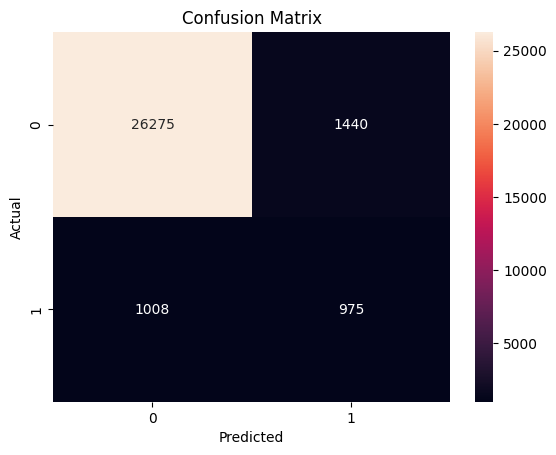

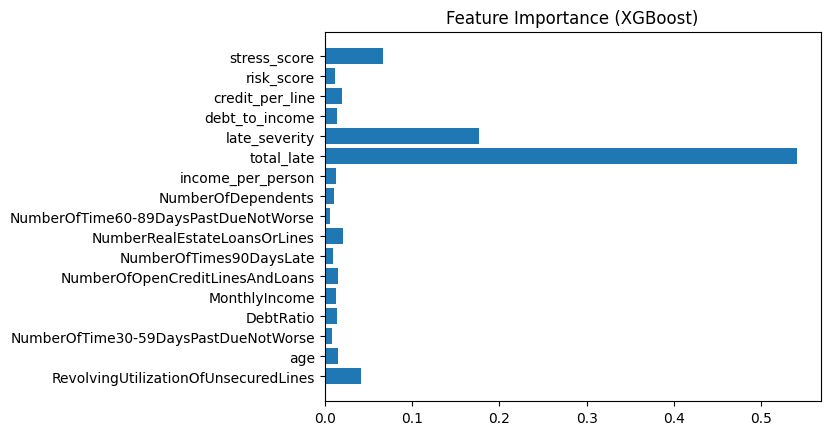

In [4]:
# ================================
# 1. INSTALL
# ================================
!pip install xgboost lightgbm

# ================================
# 2. IMPORTS
# ================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    auc
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# 3. LOAD DATA
# ================================
df = pd.read_csv("cleaned_credit.csv")

# ================================
# 4. HANDLE MISSING VALUES
# ================================
df["MonthlyIncome"].fillna(df["MonthlyIncome"].median(), inplace=True)
df["NumberOfDependents"].fillna(0, inplace=True)

# ================================
# 5. ADVANCED FEATURE ENGINEERING
# ================================

df["income_per_person"] = df["MonthlyIncome"] / (df["NumberOfDependents"] + 1)

df["total_late"] = (
    df["NumberOfTimes90DaysLate"] +
    df["NumberOfTime30-59DaysPastDueNotWorse"] +
    df["NumberOfTime60-89DaysPastDueNotWorse"]
)

df["late_severity"] = (
    df["NumberOfTimes90DaysLate"] * 3 +
    df["NumberOfTime60-89DaysPastDueNotWorse"] * 2 +
    df["NumberOfTime30-59DaysPastDueNotWorse"]
)

df["debt_to_income"] = df["DebtRatio"] / (df["MonthlyIncome"] + 1)

df["credit_per_line"] = df["RevolvingUtilizationOfUnsecuredLines"] / (
    df["NumberOfOpenCreditLinesAndLoans"] + 1
)

# 🔥 NEW INTERACTION FEATURES
df["risk_score"] = df["late_severity"] * df["DebtRatio"]
df["stress_score"] = df["total_late"] / (df["MonthlyIncome"] + 1)

# ================================
# 6. REMOVE OUTLIERS
# ================================
df = df[df["age"] > 18]
df = df[df["DebtRatio"] < df["DebtRatio"].quantile(0.99)]

# ================================
# 7. SPLIT
# ================================
X = df.drop("default", axis=1)
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ================================
# 8. SCALE
# ================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ================================
# 9. CLASS IMBALANCE RATIO
# ================================
ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# ================================
# 10. MODELS
# ================================

# XGBoost
xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    eval_metric="aucpr",
    random_state=42
)

# LightGBM
lgb_model = LGBMClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    class_weight="balanced",
    random_state=42
)

# ================================
# 11. TRAIN
# ================================
xgb_model.fit(X_train_scaled, y_train)
lgb_model.fit(X_train_scaled, y_train)

# ================================
# 12. ENSEMBLE PREDICTION
# ================================
xgb_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]
lgb_prob = lgb_model.predict_proba(X_test_scaled)[:, 1]

y_prob = (xgb_prob + lgb_prob) / 2

# ================================
# 13. PRECISION-RECALL CURVE
# ================================
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_idx = np.argmax(f1_scores)

best_thresh = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print("Best Threshold:", round(best_thresh, 3))
print("Best F1 Score:", round(best_f1, 3))

# ================================
# 14. FINAL PREDICTION
# ================================
y_pred = (y_prob > best_thresh).astype(int)

# ================================
# 15. EVALUATION
# ================================
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = auc(recall, precision)

print("\nROC-AUC:", round(roc_auc, 3))
print("PR-AUC:", round(pr_auc, 3))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ================================
# 16. CONFUSION MATRIX
# ================================
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ================================
# 17. FEATURE IMPORTANCE (XGB)
# ================================
plt.figure()
plt.barh(X.columns, xgb_model.feature_importances_)
plt.title("Feature Importance (XGBoost)")
plt.show()

In [1]:
!pip install shap

import shap

In [5]:
# Use XGBoost model (best for SHAP)
explainer = shap.Explainer(xgb_model, X_train_scaled)

shap_values = explainer(X_test_scaled)

100%|===================| 29688/29698 [07:23<00:00]       

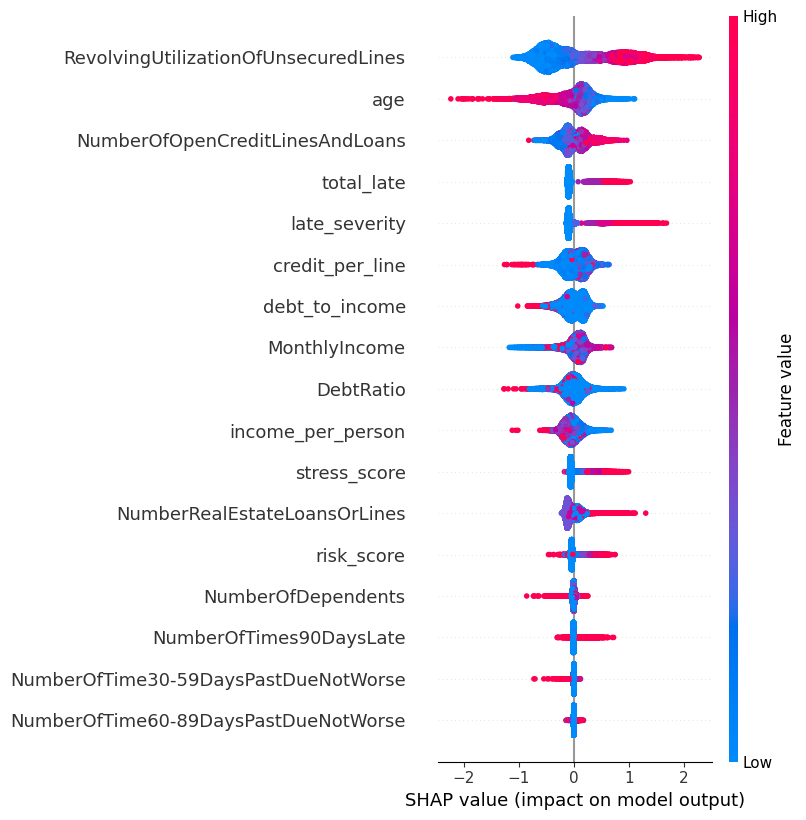

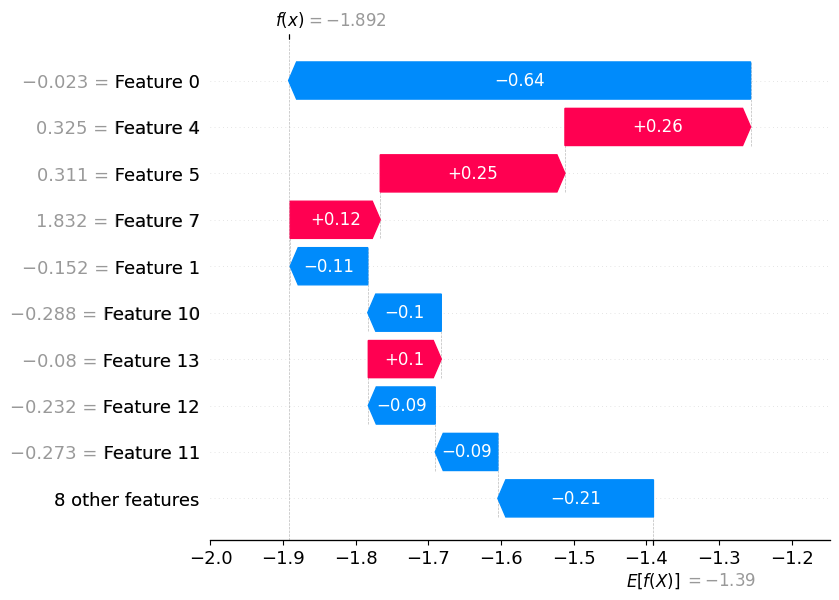

In [6]:
shap.summary_plot(shap_values, X_test)
# Explain one user
i = 10  # any index

shap.plots.waterfall(shap_values[i])

In [7]:
import pickle

pickle.dump(xgb_model, open("xgb_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))